# EfficientNetB0 Model

##### Initial Setup

In [25]:
import sys
import time
import os
import json
import zipfile
from pathlib import Path

import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping


from google.colab import drive

drive.mount("/content/drive")

DRIVE_PROJECT = Path("/content/drive/MyDrive/CSE475_Project")

DATASET_ZIP = DRIVE_PROJECT / "data" / "intel_dataset.zip"

COLAB_DATA_DIR = Path("/content/data")
COLAB_DATA_DIR.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT = DRIVE_PROJECT

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from models.efficientnet import build_efficientnet
from augmentation.augmentations import get_basic_augmentation, get_advanced_augmentation

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##### Dataset Setup

In [26]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32
SEED = 42
EPOCHS = 15

DATASET_DIR = COLAB_DATA_DIR / "intel_dataset"

if not DATASET_DIR.exists():
    with zipfile.ZipFile(DATASET_ZIP, "r") as zip_ref:
        zip_ref.extractall(COLAB_DATA_DIR)

print("Dataset path:", DATASET_DIR)

class_names = sorted([
    folder.name
    for folder in DATASET_DIR.iterdir()
    if folder.is_dir()
])

num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)


file_paths = []
labels = []

VALID_EXTENSIONS = {".jpg", ".jpeg", ".png"}

for label, class_name in enumerate(class_names):
    class_dir = DATASET_DIR / class_name

    for file_path in sorted(class_dir.iterdir()):
        if file_path.is_file() and file_path.suffix.lower() in VALID_EXTENSIONS:
            file_paths.append(str(file_path))
            labels.append(label)

print("Total images:", len(file_paths))

Dataset path: /content/data/intel_dataset
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Number of classes: 6
Total images: 16900


##### Train Test Split

In [27]:
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    file_paths,
    labels,
    test_size=0.30,
    random_state=SEED,
    stratify=labels
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_labels
)

print("Train images:", len(train_paths))
print("Validation images:", len(val_paths))
print("Test images:", len(test_paths))

Train images: 11830
Validation images: 2535
Test images: 2535


##### Preprocessing

In [28]:
def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

    return image, label

#### Experiment 1 | EfficientNetB0 with Basic Augmentation

##### Augmentation

In [5]:
data_augmentation = get_basic_augmentation()

##### Creating TensorFlow Datasets

In [30]:
def make_efficientnet_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    ds = ds.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if training:
        ds = ds.shuffle(
            buffer_size=len(paths),
            seed=SEED
        )

        ds = ds.map(
            lambda x, y: (
                data_augmentation(x, training=True),
                y
            ),
            num_parallel_calls=tf.data.AUTOTUNE
        )

    ds = ds.map(
    lambda x, y: (
        tf.clip_by_value(x, 0.0, 1.0) * 255.0,
        y
    ),
    num_parallel_calls=tf.data.AUTOTUNE
)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds


train_ds = make_efficientnet_dataset(
    train_paths,
    train_labels,
    training=True
)

val_ds = make_efficientnet_dataset(
    val_paths,
    val_labels,
    training=False
)

test_ds = make_efficientnet_dataset(
    test_paths,
    test_labels,
    training=False
)

##### Setting Up the Model

In [14]:
efficientnet_basic_model = build_efficientnet(
    num_classes=num_classes,
    input_shape=(*IMG_SIZE, 3)
)

efficientnet_basic_model.summary()

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 5, 5, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,057,257 (15.48 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

##### Training the Model

In [8]:
start_time = time.time()

efficientnet_basic_history = efficientnet_basic_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop]
)

end_time = time.time()

efficientnet_basic_training_time = end_time - start_time

Epoch 1/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 138s 271ms/step - accuracy: 0.8456 - loss: 0.4560 - val_accuracy: 0.9112 - val_loss: 0.2437
Epoch 2/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 68s 174ms/step - accuracy: 0.8986 - loss: 0.2863 - val_accuracy: 0.9172 - val_loss: 0.2192
Epoch 3/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 67s 171ms/step - accuracy: 0.9023 - loss: 0.2663 - val_accuracy: 0.9164 - val_loss: 0.2247
Epoch 4/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 84s 173ms/step - accuracy: 0.9010 - loss: 0.2552 - val_accuracy: 0.9223 - val_loss: 0.2037
Epoch 5/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 82s 171ms/step - accuracy: 0.9066 - loss: 0.2446 - val_accuracy: 0.9250 - val_loss: 0.2008
Epoch 6/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 69s 173ms/step - accuracy: 0.9101 - loss: 0.2430 - val_accuracy: 0.9266 - val_loss: 0.2010
Epoch 7/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 71s 180ms/step - accuracy: 0.9112 - loss: 0.2360 - val_accuracy: 0.9195 - val_loss: 0.2108
Epoch 8/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 72s 177ms/step - accuracy: 0.9119 - loss: 

##### Evaluation

80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9235 - loss: 0.2177
80/80 ━━━━━━━━━━━━━━━━━━━━ 23s 128ms/step
Test Loss: 0.21773719787597656
Test Accuracy: 0.9234713912010193
Weighted F1 Score: 0.923382140842769
Weighted ROC-AUC: 0.9930188264888717
Training Time (seconds): 873.96


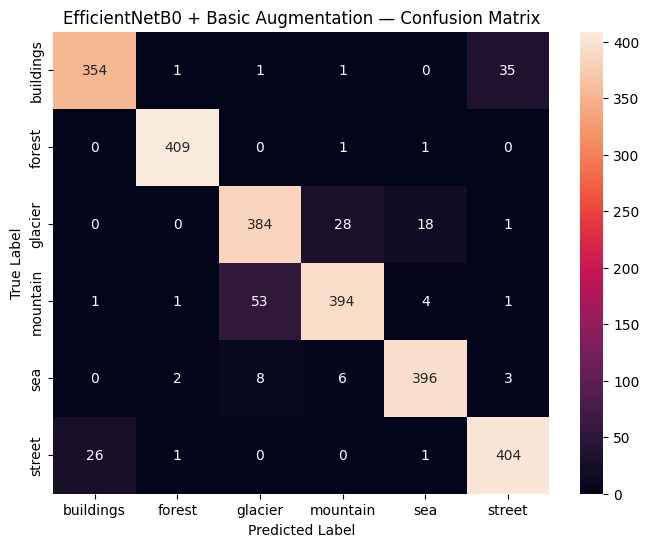

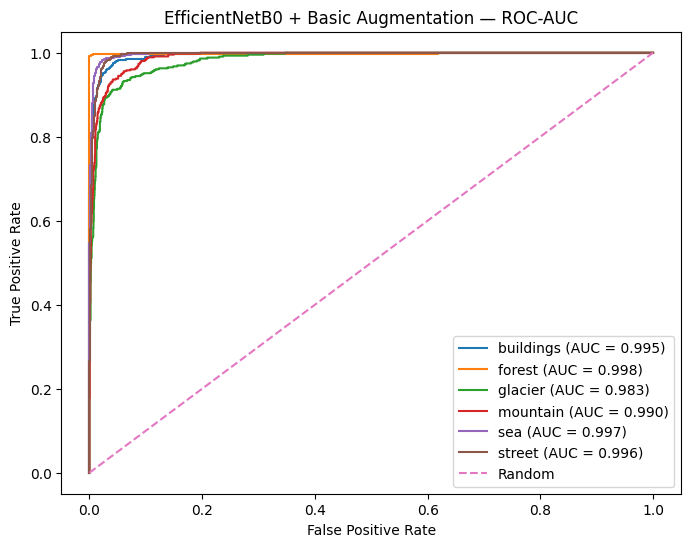

In [9]:
from sklearn.metrics import (
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


efficientnet_basic_test_loss, efficientnet_basic_test_acc = (
    efficientnet_basic_model.evaluate(test_ds)
)

y_true = np.concatenate(
    [y for x, y in test_ds],
    axis=0
)

y_pred_probs = efficientnet_basic_model.predict(test_ds)

y_pred = np.argmax(
    y_pred_probs,
    axis=1
)

efficientnet_basic_waf1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

efficientnet_basic_cm = confusion_matrix(
    y_true,
    y_pred
)

y_true_bin = label_binarize(
    y_true,
    classes=np.arange(len(class_names))
)

efficientnet_basic_roc_auc = roc_auc_score(
    y_true_bin,
    y_pred_probs,
    multi_class="ovr",
    average="weighted"
)

print("Test Loss:", efficientnet_basic_test_loss)
print("Test Accuracy:", efficientnet_basic_test_acc)
print("Weighted F1 Score:", efficientnet_basic_waf1)
print("Weighted ROC-AUC:", efficientnet_basic_roc_auc)
print(
    "Training Time (seconds):",
    round(efficientnet_basic_training_time, 2)
)

FIGURE_DIR = DRIVE_PROJECT / "results" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8, 6))

sns.heatmap(
    efficientnet_basic_cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(
    "EfficientNetB0 + Basic Augmentation — Confusion Matrix"
)

plt.savefig(
    FIGURE_DIR /
    "efficientnet_basic_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.figure(figsize=(8, 6))

for i, class_name in enumerate(class_names):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        y_pred_probs[:, i]
    )

    class_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} (AUC = {class_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "EfficientNetB0 + Basic Augmentation — ROC-AUC"
)

plt.legend()

plt.savefig(
    FIGURE_DIR /
    "efficientnet_basic_roc_auc.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

##### Saving the Trained Model

In [10]:
MODEL_DIR = (
    DRIVE_PROJECT /
    "saved_models" /
    "efficientnet_basic"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODEL_PATH = (
    MODEL_DIR /
    "efficientnet_b0_basic.keras"
)

efficientnet_basic_model.save(MODEL_PATH)

print("Model saved to:", MODEL_PATH)

Model saved to: /content/drive/MyDrive/CSE475_Project/saved_models/efficientnet_basic/efficientnet_b0_basic.keras


##### Saving Training History

In [11]:
HISTORY_DIR = (
    DRIVE_PROJECT /
    "results" /
    "metrics"
)

HISTORY_DIR.mkdir(
    parents=True,
    exist_ok=True
)

history_path = (
    HISTORY_DIR /
    "efficientnet_b0_basic_history.json"
)

with open(history_path, "w") as f:
    json.dump(
        efficientnet_basic_history.history,
        f
    )

print("Training history saved to:", history_path)

Training history saved to: /content/drive/MyDrive/CSE475_Project/results/metrics/efficientnet_b0_basic_history.json


##### Saving Evaluation Metrics

In [12]:
metrics_path = (
    HISTORY_DIR /
    "efficientnet_b0_basic_metrics.json"
)

metrics = {
    "test_loss": float(efficientnet_basic_test_loss),
    "test_accuracy": float(efficientnet_basic_test_acc),
    "weighted_f1": float(efficientnet_basic_waf1),
    "weighted_roc_auc": float(efficientnet_basic_roc_auc),
    "training_time_seconds": float(
        efficientnet_basic_training_time
    )
}

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=4)

print("Evaluation metrics saved to:", metrics_path)

Evaluation metrics saved to: /content/drive/MyDrive/CSE475_Project/results/metrics/efficientnet_b0_basic_metrics.json


#### Experiment 2 | EfficientNetB0 with Advanced Augmentation

##### Augmentation

In [31]:
import sys
import importlib

PROJECT_ROOT = "/content/drive/MyDrive/CSE475_Project"

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

import augmentation.augmentations as augmentations

importlib.reload(augmentations)

get_basic_augmentation = augmentations.get_basic_augmentation
get_advanced_augmentation = augmentations.get_advanced_augmentation

data_augmentation = get_advanced_augmentation()

##### Creating TensorFlow Datasets

In [32]:
train_ds = make_efficientnet_dataset(
    train_paths,
    train_labels,
    training=True
)

val_ds = make_efficientnet_dataset(
    val_paths,
    val_labels,
    training=False
)

test_ds = make_efficientnet_dataset(
    test_paths,
    test_labels,
    training=False
)

In [33]:
images, labels = next(iter(train_ds))

print("Min:", tf.reduce_min(images).numpy())
print("Max:", tf.reduce_max(images).numpy())
print("Mean:", tf.reduce_mean(images).numpy())
print("Std:", tf.math.reduce_std(images).numpy())

Min: 0.0
Max: 255.0
Mean: 107.42505
Std: 81.63163


##### Setting Up the Model

In [34]:
efficientnet_advanced_model = build_efficientnet(
    num_classes=num_classes,
    input_shape=(*IMG_SIZE, 3)
)

efficientnet_advanced_model.summary()

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 5, 5, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,057,257 (15.48 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

##### Training the Model

In [35]:
start_time = time.time()

efficientnet_advanced_history = (
    efficientnet_advanced_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=[early_stop]
    )
)

end_time = time.time()

efficientnet_advanced_training_time = (
    end_time - start_time
)

Epoch 1/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 224s 522ms/step - accuracy: 0.7495 - loss: 0.6650 - val_accuracy: 0.8856 - val_loss: 0.3244
Epoch 2/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 172s 450ms/step - accuracy: 0.8227 - loss: 0.4658 - val_accuracy: 0.9034 - val_loss: 0.2759
Epoch 3/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 206s 465ms/step - accuracy: 0.8277 - loss: 0.4373 - val_accuracy: 0.8994 - val_loss: 0.2653
Epoch 4/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 198s 454ms/step - accuracy: 0.8365 - loss: 0.4295 - val_accuracy: 0.9045 - val_loss: 0.2695
Epoch 5/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 169s 446ms/step - accuracy: 0.8385 - loss: 0.4154 - val_accuracy: 0.9030 - val_loss: 0.2566
Epoch 6/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 171s 445ms/step - accuracy: 0.8404 - loss: 0.4133 - val_accuracy: 0.9010 - val_loss: 0.2609
Epoch 7/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 202s 449ms/step - accuracy: 0.8459 - loss: 0.4049 - val_accuracy: 0.9010 - val_loss: 0.2591
Epoch 8/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 203s 451ms/step - accuracy: 0.8441 -

##### Evaluation

80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9018 - loss: 0.2726
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step
Test Loss: 0.2725909650325775
Test Accuracy: 0.9017751216888428
Weighted F1 Score: 0.9014724740472386
Weighted ROC-AUC: 0.9894390240429799
Training Time (seconds): 1544.34


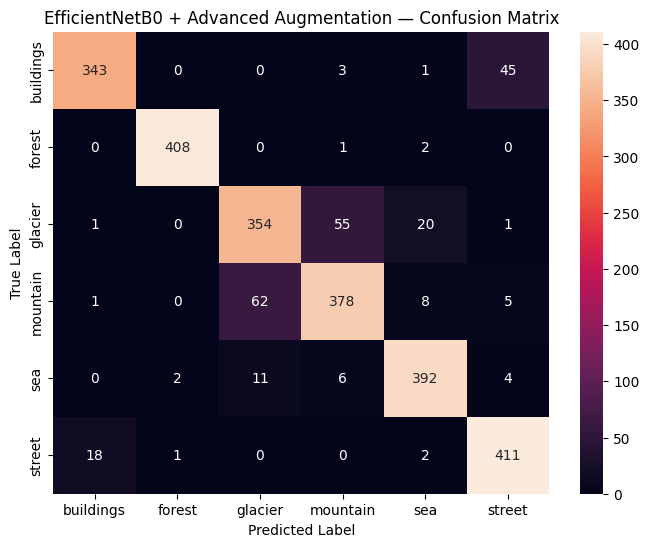

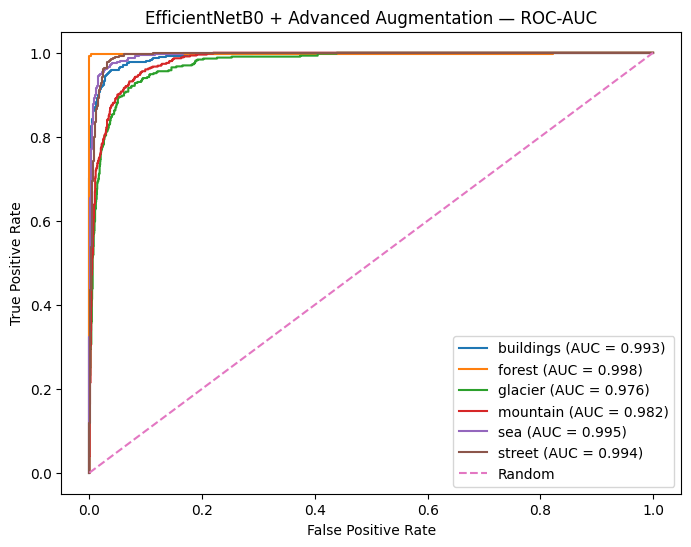

In [40]:
from sklearn.metrics import (
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

efficientnet_advanced_test_loss, efficientnet_advanced_test_acc = (
    efficientnet_advanced_model.evaluate(test_ds)
)

y_true_advanced = np.concatenate(
    [y for x, y in test_ds],
    axis=0
)

y_pred_probs_advanced = (
    efficientnet_advanced_model.predict(test_ds)
)

y_pred_advanced = np.argmax(
    y_pred_probs_advanced,
    axis=1
)

efficientnet_advanced_waf1 = f1_score(
    y_true_advanced,
    y_pred_advanced,
    average="weighted"
)

efficientnet_advanced_cm = confusion_matrix(
    y_true_advanced,
    y_pred_advanced
)

y_true_advanced_bin = label_binarize(
    y_true_advanced,
    classes=np.arange(len(class_names))
)

efficientnet_advanced_roc_auc = roc_auc_score(
    y_true_advanced_bin,
    y_pred_probs_advanced,
    multi_class="ovr",
    average="weighted"
)

print("Test Loss:", efficientnet_advanced_test_loss)
print("Test Accuracy:", efficientnet_advanced_test_acc)
print(
    "Weighted F1 Score:",
    efficientnet_advanced_waf1
)
print(
    "Weighted ROC-AUC:",
    efficientnet_advanced_roc_auc
)
print(
    "Training Time (seconds):",
    round(efficientnet_advanced_training_time, 2)
)

FIGURE_DIR = DRIVE_PROJECT / "results" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8, 6))

sns.heatmap(
    efficientnet_advanced_cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title(
    "EfficientNetB0 + Advanced Augmentation — "
    "Confusion Matrix"
)

plt.savefig(
    FIGURE_DIR /
    "efficientnet_advanced_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.figure(figsize=(8, 6))

for i, class_name in enumerate(class_names):

    fpr, tpr, _ = roc_curve(
        y_true_advanced_bin[:, i],
        y_pred_probs_advanced[:, i]
    )

    class_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} (AUC = {class_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "EfficientNetB0 + Advanced Augmentation — ROC-AUC"
)

plt.legend()

plt.savefig(
    FIGURE_DIR /
    "efficientnet_advanced_roc_auc.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

##### Saving the Model

In [41]:
MODEL_DIR = (
    DRIVE_PROJECT /
    "saved_models" /
    "efficientnet_advanced"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODEL_PATH = (
    MODEL_DIR /
    "efficientnet_b0_advanced.keras"
)

efficientnet_advanced_model.save(MODEL_PATH)

print("Model saved to:", MODEL_PATH)

Model saved to: /content/drive/MyDrive/CSE475_Project/saved_models/efficientnet_advanced/efficientnet_b0_advanced.keras


##### Saving Training History

In [43]:
HISTORY_DIR = (
    DRIVE_PROJECT /
    "results" /
    "metrics"
)

HISTORY_DIR.mkdir(
    parents=True,
    exist_ok=True
)

history_path = (
    HISTORY_DIR /
    "efficientnet_b0_advanced_history.json"
)

with open(history_path, "w") as f:
    json.dump(
        efficientnet_advanced_history.history,
        f
    )

print("Training history saved to:", history_path)

Training history saved to: /content/drive/MyDrive/CSE475_Project/results/metrics/efficientnet_b0_advanced_history.json


##### Saving Evaluation Metrics

In [44]:
metrics_path = (
    HISTORY_DIR /
    "efficientnet_b0_advanced_metrics.json"
)

metrics = {
    "test_loss": float(efficientnet_advanced_test_loss),
    "test_accuracy": float(efficientnet_advanced_test_acc),
    "weighted_f1": float(efficientnet_advanced_waf1),
    "weighted_roc_auc": float(
        efficientnet_advanced_roc_auc
    ),
    "training_time_seconds": float(
        efficientnet_advanced_training_time
    )
}

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=4)

print("Evaluation metrics saved to:", metrics_path)

Evaluation metrics saved to: /content/drive/MyDrive/CSE475_Project/results/metrics/efficientnet_b0_advanced_metrics.json
